In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.stats import chi2
import math as math
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import selfmadefunctions
import importlib
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

<module 'selfmadefunctions' from 'c:\\Users\\manou\\OneDrive\\Documenten\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

In [94]:
# Generate lists and data
NETWORK_FOLDER = Path(rf"Z:\Clean_Data\Data_Manou_Maria_Clean")
T3_Thicknesses = [0, 20, 40, 60, 80, 100, 140, 180, 200, 250, 300, 350, 400, 500]
V_Thicknesses = [0, 1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40]

# Liesker-Kieft Data
T_COR, T_COR_err = selfmadefunctions.calulate_COR(NETWORK_FOLDER, 'T3', T3_Thicknesses, 3, False) # (networkfolder, filebegin, thicknesslist, repetitions, Plot)
V_COR, V_COR_err = selfmadefunctions.calulate_COR(NETWORK_FOLDER, 'V', V_Thicknesses, 3, False)

# 1st year Data
A4_Thickness, A4_COR, A4_COR_err = selfmadefunctions.read_saladin_data("A4_sanitized_data.csv", False)
A5B_Thickness, A5B_COR, A5B_COR_err = selfmadefunctions.read_saladin_data("A5_B_sanitized_data.csv", False)
A5O_Thickness, A5O_COR, A5O_COR_err = selfmadefunctions.read_saladin_data("A5_O_sanitized_data.csv", False)


# Vacuum Data
NETWORK_FOLDER = Path(rf"Z:\Clean_Data\Data_Pressure_Clean")

_17_7_Pressure = [40, 100, 200, 410, 540, 755, 1018.5]
_17_7_COR = []
_17_7_COR_err = []

_18_7_Pressure = [40, 95, 100, 190, 200, 300, 410, 540, 775, 1018.5]
_18_7_COR = []
_18_7_COR_err = []

_22_7_Thickness = [1, 5, 10, 50, 150, 200, 250, 300]
_22_7_COR = []
_22_7_COR_err = []

for p in _17_7_Pressure:
    COR, COR_err = selfmadefunctions.calculate_COR_Vacuum(NETWORK_FOLDER, f"17-7_Results_100_{p}mbar_clean", _17_7_Pressure)
    _17_7_COR.append(COR) 
    _17_7_COR_err.append(COR_err)

for p in _18_7_Pressure:
    COR, COR_err = selfmadefunctions.calculate_COR_Vacuum(NETWORK_FOLDER, f"18-7_Results_100_{p}mbar_clean", _17_7_Pressure)
    _18_7_COR.append(COR) 
    _18_7_COR_err.append(COR_err)

for t in _22_7_Thickness:
    COR, COR_err = selfmadefunctions.calculate_COR_Vacuum(NETWORK_FOLDER, f"22-7_Results_{t}_30mbar_clean", _17_7_Pressure)
    _22_7_COR.append(COR) 
    _22_7_COR_err.append(COR_err)

Below I used the self made functions in selfmadefunctions.py to reprocess the data from 2024 I collected with Maria.

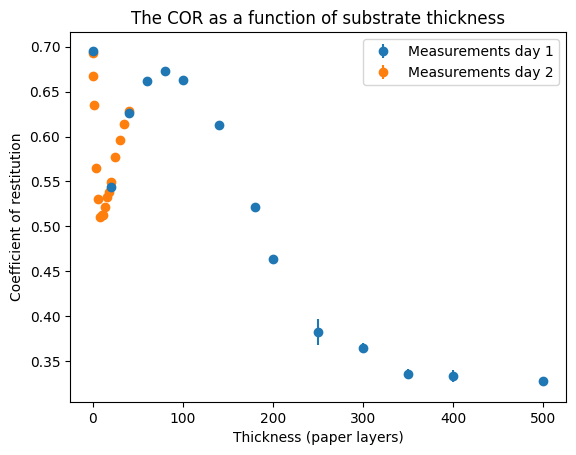

In [74]:
plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1", zorder = 1)
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2", zorder = 0)
plt.title('The COR as a function of substrate thickness')
plt.xlabel('Thickness (paper layers)')
plt.ylabel('Coefficient of restitution')
plt.legend()
plt.show()

I will now recreate 1st year students graph and combine with my graph. I would like his raw data to compare our data analysis methods.

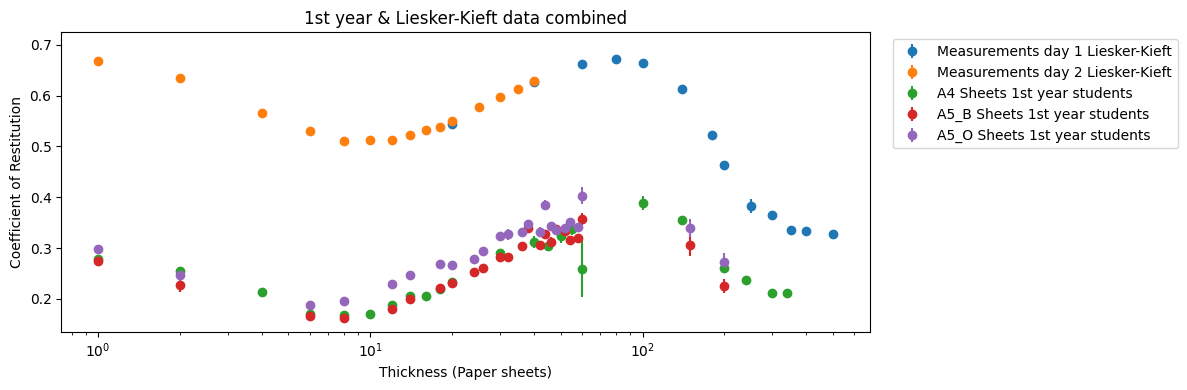

In [9]:
plt.figure(figsize = (12,4))
plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1 Liesker-Kieft")
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2 Liesker-Kieft")
plt.errorbar(A4_Thickness, A4_COR, yerr = A4_COR_err, fmt = 'o', label = 'A4 Sheets 1st year students')
plt.errorbar(A5B_Thickness, A5B_COR, yerr = A5B_COR_err, fmt = 'o', label = 'A5_B Sheets 1st year students')
plt.errorbar(A5O_Thickness, A5O_COR, yerr = A5O_COR_err, fmt = 'o', label = 'A5_O Sheets 1st year students')
plt.title("1st year & Liesker-Kieft data combined")
plt.xlabel("Thickness (Paper sheets)")
plt.ylabel("Coefficient of Restitution")
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Here are the experiments done in a vacuum chamber. I'd like to repeate these measurements with 3 or more repetitions per  thickness/pressure, so we cam get clearer data. I am not aware of the errors on the measurements, I put 0.02.

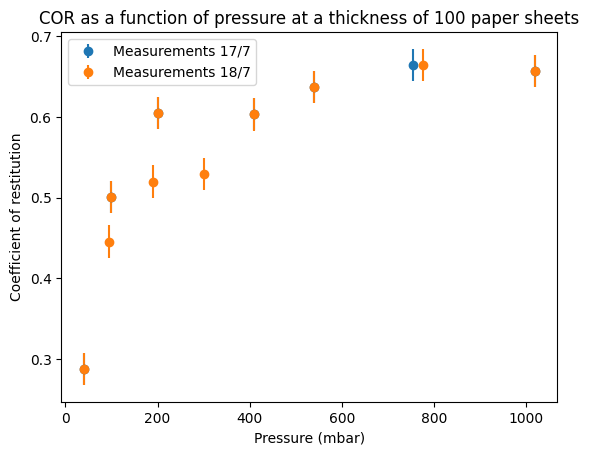

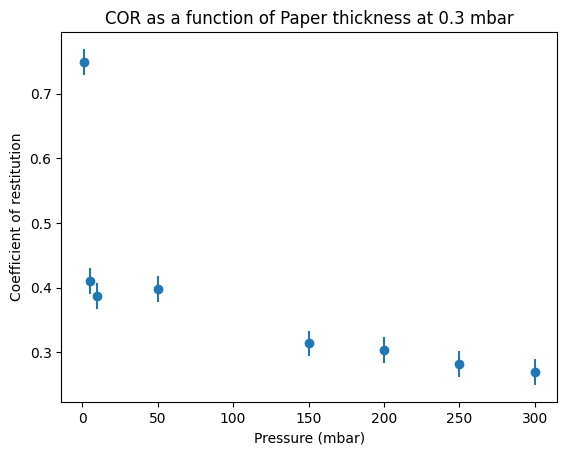

In [96]:
plt.errorbar(_17_7_Pressure, _17_7_COR, label = 'Measurements 17/7', yerr=0.02, fmt = 'o')
plt.errorbar(_18_7_Pressure, _18_7_COR, label = 'Measurements 18/7', yerr=0.02, fmt = 'o')
plt.title("COR as a function of pressure at a thickness of 100 paper sheets")
plt.xlabel("Pressure (mbar)")
plt.ylabel("Coefficient of restitution")
plt.legend()
plt.show()

plt.errorbar(_22_7_Thickness, _22_7_COR, yerr=0.02, fmt = 'o')
plt.title("COR as a function of Paper thickness at 0.3 mbar")
plt.xlabel("Pressure (mbar)")
plt.ylabel("Coefficient of restitution")
plt.show()

I showed my original COR graph (The one that started it all!) to a friend of mine, who said he recognised it from somewhere. Later he sent me the Weibull distribution and with the help of chatgpt I threw together a quick fit to fit it to the data. Now, this is probably just a coincidence, since I'm having a hard time connecting the two, but it's a striking similarity nonetheless.

I suppose there is a chance the curve we're studying is some sort of asymmetric Gaussian.

In [117]:


# --------------------------------------------------
# Input data: convert to clean numpy arrays
# --------------------------------------------------
t_data = np.asarray(T3_Thicknesses, dtype=float)
y_data = np.asarray(T_COR, dtype=float)

# If you intentionally want to skip the first point:
t_data = t_data[1:]
y_data = y_data[1:]

# Remove NaN/inf just in case
mask = np.isfinite(t_data) & np.isfinite(y_data)
t_data = t_data[mask]
y_data = y_data[mask]

print(T_COR_err)
err_data = np.asarray(T_COR_err, dtype=float)
print(err_data)

# apply the same slicing as the data
err_data = err_data[1:]

# apply the same finite-data mask
err_data = err_data[mask]

# avoid division by zero or negative uncertainties
err_data = np.where(err_data <= 0, np.nan, err_data)

weights = 1.0 / err_data

if len(t_data) < 3:
    raise ValueError("Not enough valid data points left to fit.")

# --------------------------------------------------
# Model function
# Shifted gamma-like curve
# For t <= t0, return 0 to avoid invalid fractional powers
# --------------------------------------------------
def fit_function(t, l, t0, k, A):
    x = (t - t0) / l
    y = np.zeros_like(x, dtype=float)

    positive = x > 0
    y[positive] = A * (k / l) * (x[positive] ** (k - 1)) * np.exp(-x[positive]) + 0.33

    return y

calibration_model = Model(fit_function)

# --------------------------------------------------
# Reasonable initial guesses
# --------------------------------------------------
A_guess = np.nanmax(y_data) if np.nanmax(y_data) > 0 else 1.0
t0_guess = np.nanmin(t_data) - 0.1 * (np.nanmax(t_data) - np.nanmin(t_data))
l_guess = max((np.nanmax(t_data) - np.nanmin(t_data)) / 5, 1e-3)
k_guess = 2.0

params = calibration_model.make_params(
    l=l_guess,
    t0=t0_guess,
    k=k_guess,
    A=A_guess,
)

# Bounds to keep the fit sane
params["l"].set(min=1e-6)
params["k"].set(min=1e-6, max=20)
params["t0"].set(min=np.nanmin(t_data) - 2 * (np.nanmax(t_data) - np.nanmin(t_data)),
                 max=np.nanmax(t_data))
params["A"].set(min=0)


# --------------------------------------------------
# Fit
# --------------------------------------------------
fit_result = calibration_model.fit(
    y_data,
    params=params,
    t=t_data,
    weights=weights
)

# Best fit on measured x values
fit_y = fit_result.best_fit
residuals = y_data - fit_y
rmse = np.sqrt(np.mean(residuals**2))

# Smooth curve for plotting
t_fine = np.linspace(np.min(t_data), np.max(t_data), 500)
fit_fine = fit_result.eval(t=t_fine)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, (ax_res, ax_main) = plt.subplots(
    2, 1,
    figsize=(6, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Residual plot
ax_res.axhline(0, linestyle="--")
ax_res.errorbar(t_data, residuals, yerr= T_COR_err[1:], fmt="o", markersize=4)
ax_res.set_ylabel("Residual")
ax_res.set_title(f"Fit quality (RMSE = {rmse:.4g})")

# Main plot
ax_main.errorbar(t_data, y_data, yerr= T_COR_err[1:], fmt="o", markersize=4, label="Data", zorder=2)
ax_main.plot(t_fine, fit_fine, label="Fit", zorder=1)

ax_main.set_xlabel("Thickness")
ax_main.set_ylabel("COR")
ax_main.set_title("Data and fit")
ax_main.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Print fit report
# --------------------------------------------------
print(fit_result.fit_report())

[np.float64(0.002684517470405755), np.float64(0.0015590849631058092), np.float64(0.0014193666861349351), np.float64(0.0016854299033080284), np.float64(0.0009761403695144044), np.float64(0.001859586752269737), np.float64(0.0015515272848737342), np.float64(0.0005217697598304889), np.float64(0.0032343939865696262), np.float64(0.01420526581725815), np.float64(0.004982222337674083), np.float64(0.004719191351257009), np.float64(0.006758739784043886), np.float64(0.004540685399419355)]


KeyboardInterrupt: 